In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)


In [4]:
df = pd.read_csv('bmw.csv')


In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [8]:
duplicates = df.duplicated().sum()

In [12]:
print(duplicates)

0


In [13]:
df = df.drop_duplicates()

In [14]:
duplicates = df.duplicated().sum()
print(duplicates)

0


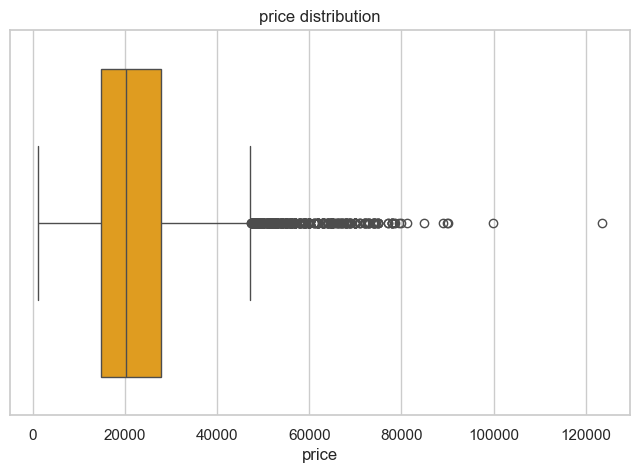

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price'], color='orange')
plt.title('price distribution')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='price', data=df, alpha=0.2)
plt.title("year vs price")
plt.xlabel("year")
plt.ylabel('price')
plt.show()

In [19]:
currnt_year = 2025
df['car_age'] = currnt_year - df['year']

In [20]:
df = df.drop("year", axis=1)

In [21]:
print(df.select_dtypes(include=['object']).columns.tolist())

['model', 'transmission', 'fuelType']


In [22]:
df = pd.get_dummies(df, drop_first=True)


In [ ]:
df.head()

In [24]:
X = df.drop('price', axis=1) 
y = df['price']              
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
len(X_train)

8531

In [26]:
len(X_test)

2133

In [38]:
model = RandomForestRegressor(n_estimators=1000, random_state=42 )
model.fit(X_train, y_train)


,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test)


In [40]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"دقت مدل (R2 Score): {r2:.2f}") 
print(f"میانگین خطا (MAE): {mae:.0f} دلار")

دقت مدل (R2 Score): 0.94
میانگین خطا (MAE): 1544 دلار


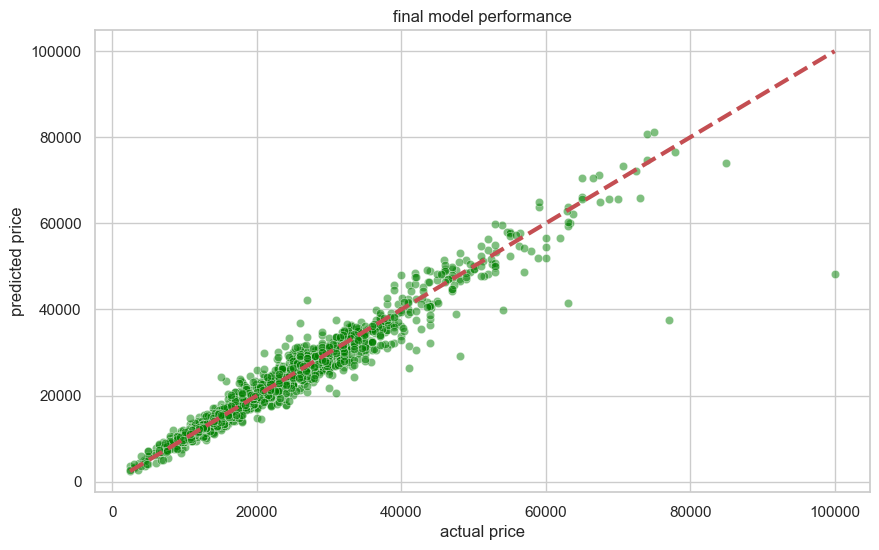

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.title('final model performance')
plt.show()

In [ ]:
sample_index = 0
sample_car = X_test.iloc[sample_index]
real_price_sample = y_test.iloc[sample_index]
predicted_price_sample = model.predict([sample_car])[0]

print(f"قیمت واقعی ماشین: {real_price_sample}$")
print(f"مدل ما حدس زد:    {predicted_price_sample:.0f}$")
print(f"اختلاف:           {abs(real_price_sample - predicted_price_sample):.0f}$")

قیمت واقعی ماشین: 59989$
مدل ما حدس زد:    54570$
اختلاف:           5419$


e:\python3.12\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\python3.12\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# تنظیمات ظاهری
sns.set(style="whitegrid")
# می‌خواهیم چه چیزی را پیش‌بینی کنیم؟
# گزینه ۱: 'transmission' (نوع دنده  )
# گزینه ۲: 'fuelType'     (نوع سوخت )

TARGET_COLUMN = 'transmission'  

print(f" هدف پروژه: پیش‌بینی ستون '{TARGET_COLUMN}'")

In [ ]:
print(df[TARGET_COLUMN].unique())
print(df[TARGET_COLUMN].value_counts())

In [ ]:
X = df.drop(columns=[TARGET_COLUMN]) 
y = df[TARGET_COLUMN] 

In [ ]:
print(X.columns.tolist())


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
model.fit(X_train, y_train)


In [ ]:
y_pred = model.predict(X_test)
